In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf

# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f"Training images shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test images shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [3]:
import numpy as np

# Normalize image pixel values from 0-255 to 0-1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape images to include a channel dimension (for CNN models)
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)

# One-hot encode the labels
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

print(f"Normalized and reshaped training images shape: {x_train.shape}")
print(f"One-hot encoded training labels shape: {y_train.shape}")
print(f"Normalized and reshaped test images shape: {x_test.shape}")
print(f"One-hot encoded test labels shape: {y_test.shape}")

Normalized and reshaped training images shape: (60000, 28, 28, 1)
One-hot encoded training labels shape: (60000, 10)
Normalized and reshaped test images shape: (10000, 28, 28, 1)
One-hot encoded test labels shape: (10000, 10)


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Initialize the Sequential model
model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

print("CNN model architecture defined successfully.")
model.summary()

CNN model architecture defined successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("CNN model compiled successfully.")

CNN model compiled successfully.


In [6]:
history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_split=0.2)
print("Model training completed.")

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 31ms/step - accuracy: 0.9039 - loss: 0.3322 - val_accuracy: 0.9841 - val_loss: 0.0533
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 33ms/step - accuracy: 0.9860 - loss: 0.0458 - val_accuracy: 0.9873 - val_loss: 0.0458
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9912 - loss: 0.0281 - val_accuracy: 0.9891 - val_loss: 0.0395
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9928 - loss: 0.0217 - val_accuracy: 0.9892 - val_loss: 0.0383
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 30ms/step - accuracy: 0.9963 - loss: 0.0130 - val_accuracy: 0.9897 - val_loss: 0.0367
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9964 - loss: 0.0106 - val_accuracy: 0.9904 - val_loss: 0.0367
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9976 - loss: 0.0080 - val_accuracy: 0.9893 - val_loss: 0.0451
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9975 -

In [7]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [8]:
# Training the model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 99ms/step - accuracy: 0.9981 - loss: 0.0077 - val_accuracy: 0.9922 - val_loss: 0.0400
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9927 - val_loss: 0.0387
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9998 - loss: 9.3490e-04 - val_accuracy: 0.9938 - val_loss: 0.0386
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 81s 96ms/step - accuracy: 0.9999 - loss: 3.8292e-04 - val_accuracy: 0.9915 - val_loss: 0.0525
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.9987 - loss: 0.0036 - val_accuracy: 0.9933 - val_loss: 0.0436
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 98ms/step - accuracy: 0.9997 - loss: 7.5933e-04 - val_accuracy: 0.9932 - val_loss: 0.0565
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 95ms/step - accuracy: 0.9994 - loss: 0.0020 - val_accuracy: 0.9932 - val_loss: 0.0476
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.9991 - los

In [13]:
# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"Test Accuracy:  {test_acc * 100:.2f}%")
print(f"Test Loss:      {test_loss:.4f}")


Test Accuracy:  99.37%
Test Loss:      0.0309


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted digits: [7 2 1 0 4]
Actual digits:    [7 2 1 0 4]


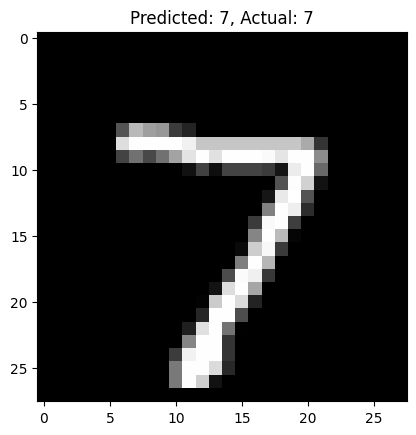

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Select the first 5 images from the test set
sample_images = x_test[:5]
actual_labels = np.argmax(y_test[:5], axis=1)

# 2. Generate predictions (the model outputs 10 probabilities per image)
raw_predictions = model.predict(sample_images)

# 3. Use argmax to find the index with the highest probability (the predicted digit)
predicted_labels = np.argmax(raw_predictions, axis=1)

# Display Results
print(f"Predicted digits: {predicted_labels}")
print(f"Actual digits:    {actual_labels}")

# Optional: Visualize the first prediction
plt.imshow(sample_images[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {predicted_labels[0]}, Actual: {actual_labels[0]}")
plt.show()


In [11]:
import pickle
with open('mnist_nn_model.pkl', 'wb') as file:
    pickle.dump(model, file)
print("model is saved")

model is saved


In [12]:
import os
model_path='mnist_nn_model.pkl'
model_size_byte=os.path.getsize(model_path)
model_size_mb=model_size_byte/(1024*1024)
print(f"the size is '{model_path}' is :{model_size_mb:.2f}MB")

the size is 'mnist_nn_model.pkl' is :2.61MB
